### Hypothesis Contd..

In [3]:
# H0: Both group has similar distribution
# H1: Both group have different distribution

g1 = [1,2,2,2,3,4]
g2 = [3,3,4,4,4,4]

# ad the data is ordered

from scipy.stats import mannwhitneyu

m_stat, pvalue = mannwhitneyu(g1,g2)

if pvalue<0.05:
    print("Reject the null hypothesis")
    
else:
    print("Accept the null hypothesis")

Reject the null hypothesis


# EDA Case Study: E-Commerce Sales & Customer Analysis

### Business Scenario

**Company:** NovaMart — an online retail company

NovaMart sells products across multiple categories and regions. Management wants to understand:

Which products and categories drive revenue?
Which customer segments are most valuable?
Which regions perform well?
Does discounting improve sales but hurt profitability?
Are there seasonal sales patterns?
Which factors are associated with profit?
Are differences between customer groups statistically significant?

The management team has asked the Data Analyst to perform an **Exploratory Data Analysis** (EDA) and provide actionable recommendations.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("NovaMart_Raw_Dataset.csv")
df

,Order_ID,Order_Date,Customer_ID,Customer_Segment,Region,State,Category,Sub_Category,Product,Quantity,Unit_Price,Sales,Discount,Profit,Shipping_Mode,Payment_Mode,Customer_Rating,Delivery_Days,Returned
0,ORD100064,2025-08-05,CUST01529,Consumer,East,West Bengal,Technology,Accessories,Keyboard,5,2046.74,8804.09,0.140,1278.64,Standard,Credit Card,3.5,6,No
1,ORD102684,2025-03-30,CUST01447,Small Business,South,Telangana,Technology,Accessories,Keyboard,1,1071.21,1087.05,0.043,102.89,Express,UPI,4.4,2,No
2,ORD100103,2023-10-15,CUST01269,Consumer,West,Rajasthan,Technology,Phones,Smartphone A,1,837.83,861.43,0.129,84.86,Express,COD,4.5,2,No
3,ORD102692,2025-05-10,CUST01064,Consumer,South,Andhra Pradesh,Technology,Phones,Smartphone A,10,2305.26,24012.01,0.017,4348.11,Same Day,COD,5.0,1,No
4,ORD100417,2025-04-08,CUST01256,Consumer,East,Bihar,Furniture,Chairs,Ergonomic Chair,5,1065.95,4583.00,0.189,349.53,Express,Credit Card,4.6,4,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3010,ORD101639,2023-09-24,CUST01112,Consumer,West,Gujarat,Technology,Printers,Laser Printer,7,2376.68,15440.75,0.072,3642.18,Standard,UPI,4.0,4,No
3011,ORD101096,2024-04-15,CUST01321,Small Business,South,Tamil Nadu,Office Supplies,Stationery,Stapler,7,277.35,1609.89,0.218,203.17,Standard,Net Banking,3.4,5,Yes
3012,ORD101131,2023-09-15,CUST01557,Consumer,West,Rajasthan,Furniture,Tables,Work Desk,3,399.05,1050.98,0.122,122.87,Express,UPI,4.1,2,No
3013,ORD101295,2024-10-27,CUST01446,Corporate,South,Andhra Pradesh,Office Supplies,Stationery,Markers,3,401.79,1073.35,0.245,186.65,Standard,Credit Card,3.8,8,No


### Data Understanding & Exploration

In [12]:
print('No of rows :',df.shape[0])
print('No of cols :',df.shape[1])

No of rows : 3015
No of cols : 19


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          3015 non-null   object 
 1   Order_Date        3015 non-null   object 
 2   Customer_ID       3015 non-null   object 
 3   Customer_Segment  3015 non-null   object 
 4   Region            3015 non-null   object 
 5   State             2961 non-null   object 
 6   Category          3015 non-null   object 
 7   Sub_Category      3015 non-null   object 
 8   Product           3015 non-null   object 
 9   Quantity          3015 non-null   int64  
 10  Unit_Price        3015 non-null   float64
 11  Sales             3015 non-null   float64
 12  Discount          2955 non-null   float64
 13  Profit            3015 non-null   float64
 14  Shipping_Mode     3015 non-null   object 
 15  Payment_Mode      2979 non-null   object 
 16  Customer_Rating   2939 non-null   float64


In [14]:
df.describe()

,Quantity,Unit_Price,Sales,Discount,Profit,Customer_Rating,Delivery_Days
count,3015.000000,3015.000000,3015.000000,2955.000000,3015.000000,2939.000000,3015.000000
mean,3.605307,520.925177,1709.586773,0.161254,242.416706,3.979653,4.580763
std,2.322270,429.403120,2261.692637,0.091634,342.163489,0.569183,2.359951
min,0.000000,28.870000,45.890000,0.000000,-792.670000,2.100000,-1.000000
25%,2.000000,210.870000,463.225000,0.091000,58.345000,3.600000,3.000000
50%,3.000000,392.770000,1035.790000,0.146000,138.920000,4.000000,4.000000
75%,5.000000,694.090000,2139.425000,0.218000,307.680000,4.400000,7.000000
max,10.000000,3864.430000,49206.000000,0.548000,4699.400000,5.000000,9.000000


In [15]:
df.describe(include='object')

,Order_ID,Order_Date,Customer_ID,Customer_Segment,Region,State,Category,Sub_Category,Product,Shipping_Mode,Payment_Mode,Returned
count,3015,3015,3015,3015,3015,2961,3015,3015,3015,3015,2979,3015
unique,3000,1023,595,3,4,16,5,12,36,3,10,2
top,ORD102417,2023-10-15,CUST01044,Consumer,South,Tamil Nadu,Office Supplies,Phones,Metal Bookcase,Standard,UPI,No
freq,2,9,13,1582,879,222,1069,285,124,2107,1151,2769


In [20]:
df.dtypes

Order_ID             object
Order_Date           object
Customer_ID          object
Customer_Segment     object
Region               object
State                object
Category             object
Sub_Category         object
Product              object
Quantity              int64
Unit_Price          float64
Sales               float64
Discount            float64
Profit              float64
Shipping_Mode        object
Payment_Mode         object
Customer_Rating     float64
Delivery_Days         int64
Returned             object
dtype: object

In [21]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Segment', 'Region',
       'State', 'Category', 'Sub_Category', 'Product', 'Quantity',
       'Unit_Price', 'Sales', 'Discount', 'Profit', 'Shipping_Mode',
       'Payment_Mode', 'Customer_Rating', 'Delivery_Days', 'Returned'],
      dtype='object')

### Data Quality Assessment & Cleaning

In [16]:
df.duplicated().sum()

np.int64(15)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.isnull().sum()

Order_ID             0
Order_Date           0
Customer_ID          0
Customer_Segment     0
Region               0
State               53
Category             0
Sub_Category         0
Product              0
Quantity             0
Unit_Price           0
Sales                0
Discount            60
Profit               0
Shipping_Mode        0
Payment_Mode        36
Customer_Rating     75
Delivery_Days        0
Returned             0
dtype: int64

In [22]:
# fill null value Customer rating
df['Customer_Rating'].describe()

count    2925.000000
mean        3.979829
std         0.569749
min         2.100000
25%         3.600000
50%         4.000000
75%         4.400000
max         5.000000
Name: Customer_Rating, dtype: float64

In [24]:
print('Rating mean :',df['Customer_Rating'].mean())
print('Rating median :',df['Customer_Rating'].median())
print('Rating std :',df['Customer_Rating'].std())

Rating mean : 3.97982905982906
Rating median : 4.0
Rating std : 0.5697486409471448


In [25]:
df['Customer_Rating']=df['Customer_Rating'].fillna(4)

**fill null value discounts**
- We can see a relationship b/w sales and discount, so instead of filling mean or anything. we can fill by using calcution/logic.

In [ ]:
df['Discounts']=df['Discounts']

In [26]:
# fill null values of State
df['State'].value_counts()

State
Tamil Nadu        222
Karnataka         218
Telangana         213
Andhra Pradesh    205
Goa               205
Rajasthan         187
Punjab            183
Gujarat           179
Uttar Pradesh     173
Maharashtra       173
Delhi             170
Haryana           170
West Bengal       168
Bihar             167
Odisha            161
Jharkhand         153
Name: count, dtype: int64

In [27]:
df['State']=df['State'].fillna('Unknown')

In [33]:
# fill null values of Payment Mode
df['Payment_Mode'].value_counts()

Payment_Mode
UPI            1146
Credit Card     867
Net Banking     475
COD             464
Name: count, dtype: int64

In [ ]:
df['Payment_Mode']=df['Payment_Mode'].fillna('')

In [32]:
df['Payment_Mode']=df['Payment_Mode'].map({'UPI':'upi','UPI':'Upi','Credit Card':'credit card','Credit Card':'CreditCard',
'Net Banking':'NetBanking','Net Banking':'net banking','UPI':'UPI','Credit Card':'Credit Card','Net Banking':'Net Banking','COD':'COD'})

In [38]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

### Feature Engineering
- Transforming columns and adding columns.

In [35]:
df.head(10)

,Order_ID,Order_Date,Customer_ID,Customer_Segment,Region,State,Category,Sub_Category,Product,Quantity,Unit_Price,Sales,Discount,Profit,Shipping_Mode,Payment_Mode,Customer_Rating,Delivery_Days,Returned
0,ORD100064,2025-08-05,CUST01529,Consumer,East,West Bengal,Technology,Accessories,Keyboard,5,2046.74,8804.09,0.140,1278.64,Standard,Credit Card,3.5,6,No
1,ORD102684,2025-03-30,CUST01447,Small Business,South,Telangana,Technology,Accessories,Keyboard,1,1071.21,1087.05,0.043,102.89,Express,UPI,4.4,2,No
2,ORD100103,2023-10-15,CUST01269,Consumer,West,Rajasthan,Technology,Phones,Smartphone A,1,837.83,861.43,0.129,84.86,Express,COD,4.5,2,No
3,ORD102692,2025-05-10,CUST01064,Consumer,South,Andhra Pradesh,Technology,Phones,Smartphone A,10,2305.26,24012.01,0.017,4348.11,Same Day,COD,5.0,1,No
4,ORD100417,2025-04-08,CUST01256,Consumer,East,Bihar,Furniture,Chairs,Ergonomic Chair,5,1065.95,4583.00,0.189,349.53,Express,Credit Card,4.6,4,No
5,ORD101265,2024-04-29,CUST01036,Small Business,South,Telangana,Furniture,Furnishings,Curtains,2,315.71,573.00,0.144,75.22,Standard,UPI,3.3,7,No
6,ORD100094,2023-01-16,CUST01177,Corporate,South,Tamil Nadu,Office Supplies,Storage,Filing Cabinet,9,127.29,1097.39,0.042,271.92,Express,Net Banking,3.9,3,No
7,ORD101539,2024-07-30,CUST01055,Corporate,North,Uttar Pradesh,Furniture,Bookcases,Wooden Bookcase,1,950.47,819.02,0.138,77.89,Standard,Credit Card,3.9,9,No
8,ORD100568,2023-06-29,CUST01527,Small Business,North,Uttar Pradesh,Office Supplies,Storage,Storage Box,2,187.85,346.42,0.078,97.18,Standard,UPI,3.7,3,No
9,ORD101042,2024-05-25,CUST01585,Small Business,West,Goa,Office Supplies,Storage,Storage Box,3,999.39,2876.81,0.095,637.41,Express,UPI,4.2,3,No


In [58]:
df['Year']=df['Order_Date'].dt.year

### Univariate Analysis

In [41]:
def univar(x):
    fig,axes=plt.subplots(1,3,figsize=(12,4))
    sns.histplot(x=x,ax=axes[0])
    sns.kdeplot(x=x,ax=axes[1])
    sns.boxplot(x=x,ax=axes[2])

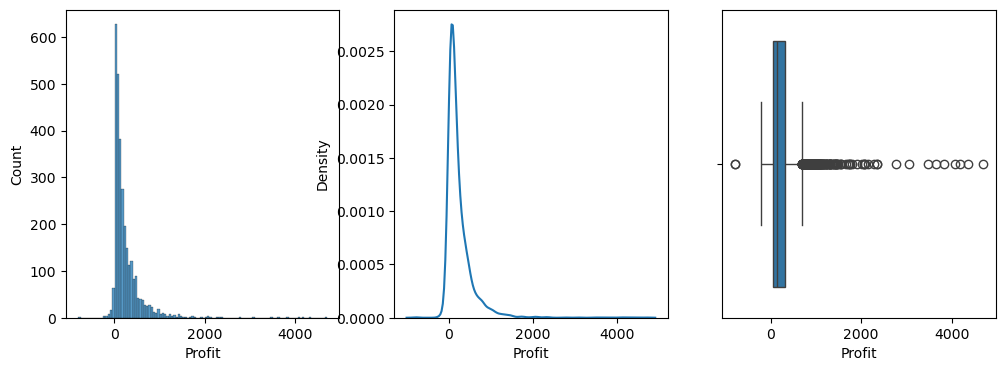

In [42]:
univar(df['Profit'])

**Obs :**
1. Majority of customers have given the profit b/w -100 to 1000 INR.
2. There were many customers who have given the profit above 1000, which goes upto 500.

In [43]:
df['Payment_Mode'].value_counts()

Payment_Mode
UPI            1146
Credit Card     867
Net Banking     475
COD             464
Name: count, dtype: int64

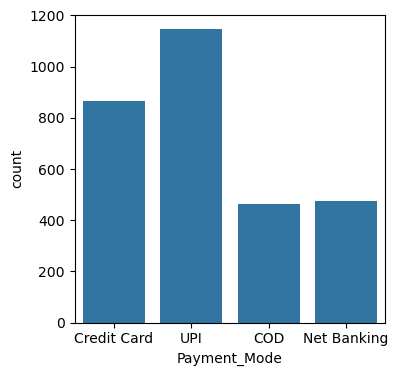

In [46]:
plt.figure(figsize=(4,4))
sns.countplot(x=df['Payment_Mode'])
plt.show()

### Bivariate Analysis

In [48]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Segment', 'Region',
       'State', 'Category', 'Sub_Category', 'Product', 'Quantity',
       'Unit_Price', 'Sales', 'Discount', 'Profit', 'Shipping_Mode',
       'Payment_Mode', 'Customer_Rating', 'Delivery_Days', 'Returned'],
      dtype='object')

In [49]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.310915
Profit,-0.310915,1.000000


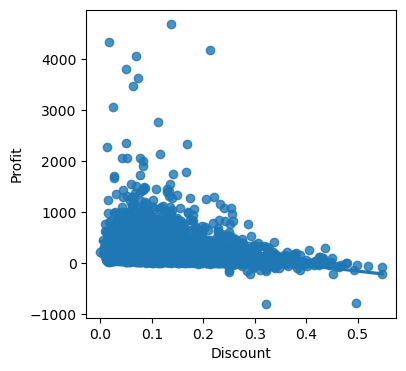

In [52]:
plt.figure(figsize=(4,4))
sns.regplot(x=df['Discount'],y=df['Profit'])
plt.show()

In [59]:
dfy=df.groupby(['Year'])[['Profit']].sum()
dfy

,Profit
Year,
2023,242649.90
2024,247432.24
2025,237296.81


### Multivariate Analysis

In [60]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Segment', 'Region',
       'State', 'Category', 'Sub_Category', 'Product', 'Quantity',
       'Unit_Price', 'Sales', 'Discount', 'Profit', 'Shipping_Mode',
       'Payment_Mode', 'Customer_Rating', 'Delivery_Days', 'Returned', 'Year'],
      dtype='object')

In [62]:
corr_mat=df[['Unit_Price', 'Sales', 'Discount', 'Profit']].corr()
corr_mat

,Unit_Price,Sales,Discount,Profit
Unit_Price,1.000000,0.658822,-0.040543,0.523253
Sales,0.658822,1.000000,-0.093328,0.846779
Discount,-0.040543,-0.093328,1.000000,-0.310915
Profit,0.523253,0.846779,-0.310915,1.000000


In [63]:
df2=df.groupby(['Region','Payment_Mode'])[['Profit','Customer_Rating']].mean()
df2

Profit  Customer_Rating
Region Payment_Mode                             
East   COD           217.199908         3.991743
       Credit Card   261.397765         3.910056
       Net Banking   273.869109         4.008911
       UPI           262.340502         3.922008
North  COD           249.982752         4.006422
       Credit Card   233.475814         3.946047
       Net Banking   238.277264         3.957547
       UPI           226.785746         3.962687
South  COD           296.589225         4.004930
       Credit Card   245.916705         3.977011
       Net Banking   222.082667         3.940741
       UPI           254.817130         4.000617
West   COD           245.648365         4.003846
       Credit Card   221.079528         4.086792
       Net Banking   250.279624         3.973684
       UPI           209.308508         4.020000

In [64]:
df2=df2.reset_index()
df2

,Region,Payment_Mode,Profit,Customer_Rating
0,East,COD,217.199908,3.991743
1,East,Credit Card,261.397765,3.910056
2,East,Net Banking,273.869109,4.008911
3,East,UPI,262.340502,3.922008
4,North,COD,249.982752,4.006422
5,North,Credit Card,233.475814,3.946047
6,North,Net Banking,238.277264,3.957547
7,North,UPI,226.785746,3.962687
8,South,COD,296.589225,4.004930
9,South,Credit Card,245.916705,3.977011


<Axes: xlabel='Region', ylabel='Profit'>

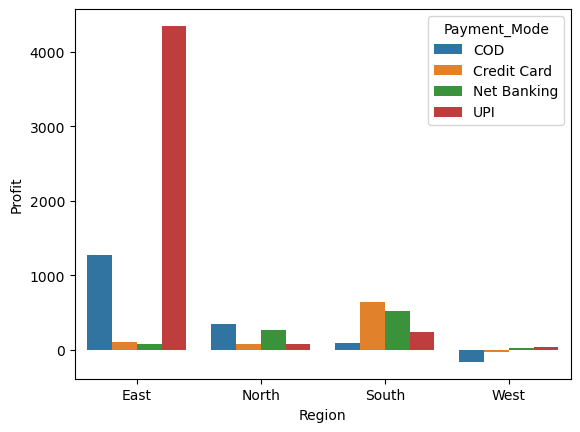

In [66]:
sns.barplot(x=df2['Region'],y=df['Profit'],hue=df2['Payment_Mode'])

### Statistical Validation
Hypothesis testing to validate important observations from Bivariate/Multivariate analysis

- Profit lies b/w -100 to 1000
- Average profit is 242

- H0 - profit lies within range
- H1 - profit doesnt not lie within the range
- consider alpha 0.05
- Test will be : ttest_1samp